In [1]:
import numpy as np
import helpers
import zarr
import mdreg

Set the right values and the directory path

In [2]:
DATASET_NAME = '159269_B1'
PART = '16'
DIR_PATH = '/mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/'

In [3]:
coreg_defo_path = f'{DIR_PATH}{DATASET_NAME}_{PART}/coreg_defo.zarr'
coreg_path = f'{DIR_PATH}{DATASET_NAME}_{PART}/coreg.zarr'
fit_path = f'{DIR_PATH}{DATASET_NAME}_{PART}/fit.zarr'
pars_path = f'{DIR_PATH}{DATASET_NAME}_{PART}/pars.zarr'

In [4]:
coreg_defo = zarr.open(coreg_defo_path)
coreg = zarr.open(coreg_path)
fit = zarr.open(fit_path)
pars = zarr.open(pars_path)

In [5]:
print(coreg_defo)
print(coreg)
print(fit)
print(pars)

<Array file:///mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/159269_B1_16/coreg_defo.zarr shape=(256, 256, 50, 250, 3) dtype=int16>
<Array file:///mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/159269_B1_16/coreg.zarr shape=(256, 256, 50, 250) dtype=int16>
<Array file:///mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/159269_B1_16/fit.zarr shape=(256, 256, 50, 250) dtype=int16>
<Array file:///mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/159269_B1_16/pars.zarr shape=(256, 256, 50, 4) dtype=int16>


In [6]:
coreg_vis = coreg[:,:,24,:]
coreg_vis = np.transpose(coreg_vis, [2,0,1])
fit_vis = fit[:,:,24,:]
fit_vis = np.transpose(fit_vis, [2,0,1])

In [7]:
helpers.explore_3D_array(coreg_vis)

interactive(children=(IntSlider(value=124, description='SLICE', max=249), Output()), _dom_classes=('widget-int…

In [8]:
helpers.explore_3D_array_comparison_and_diff(coreg_vis, fit_vis)

interactive(children=(IntSlider(value=125, description='Slice:', max=249), Output()), _dom_classes=('widget-in…

In [9]:
coreg_rotate = np.transpose(coreg, [1,0,2,3])
fit_rotate = np.transpose(fit, [1,0,2,3])

In [10]:
t0, t1 = 0,249

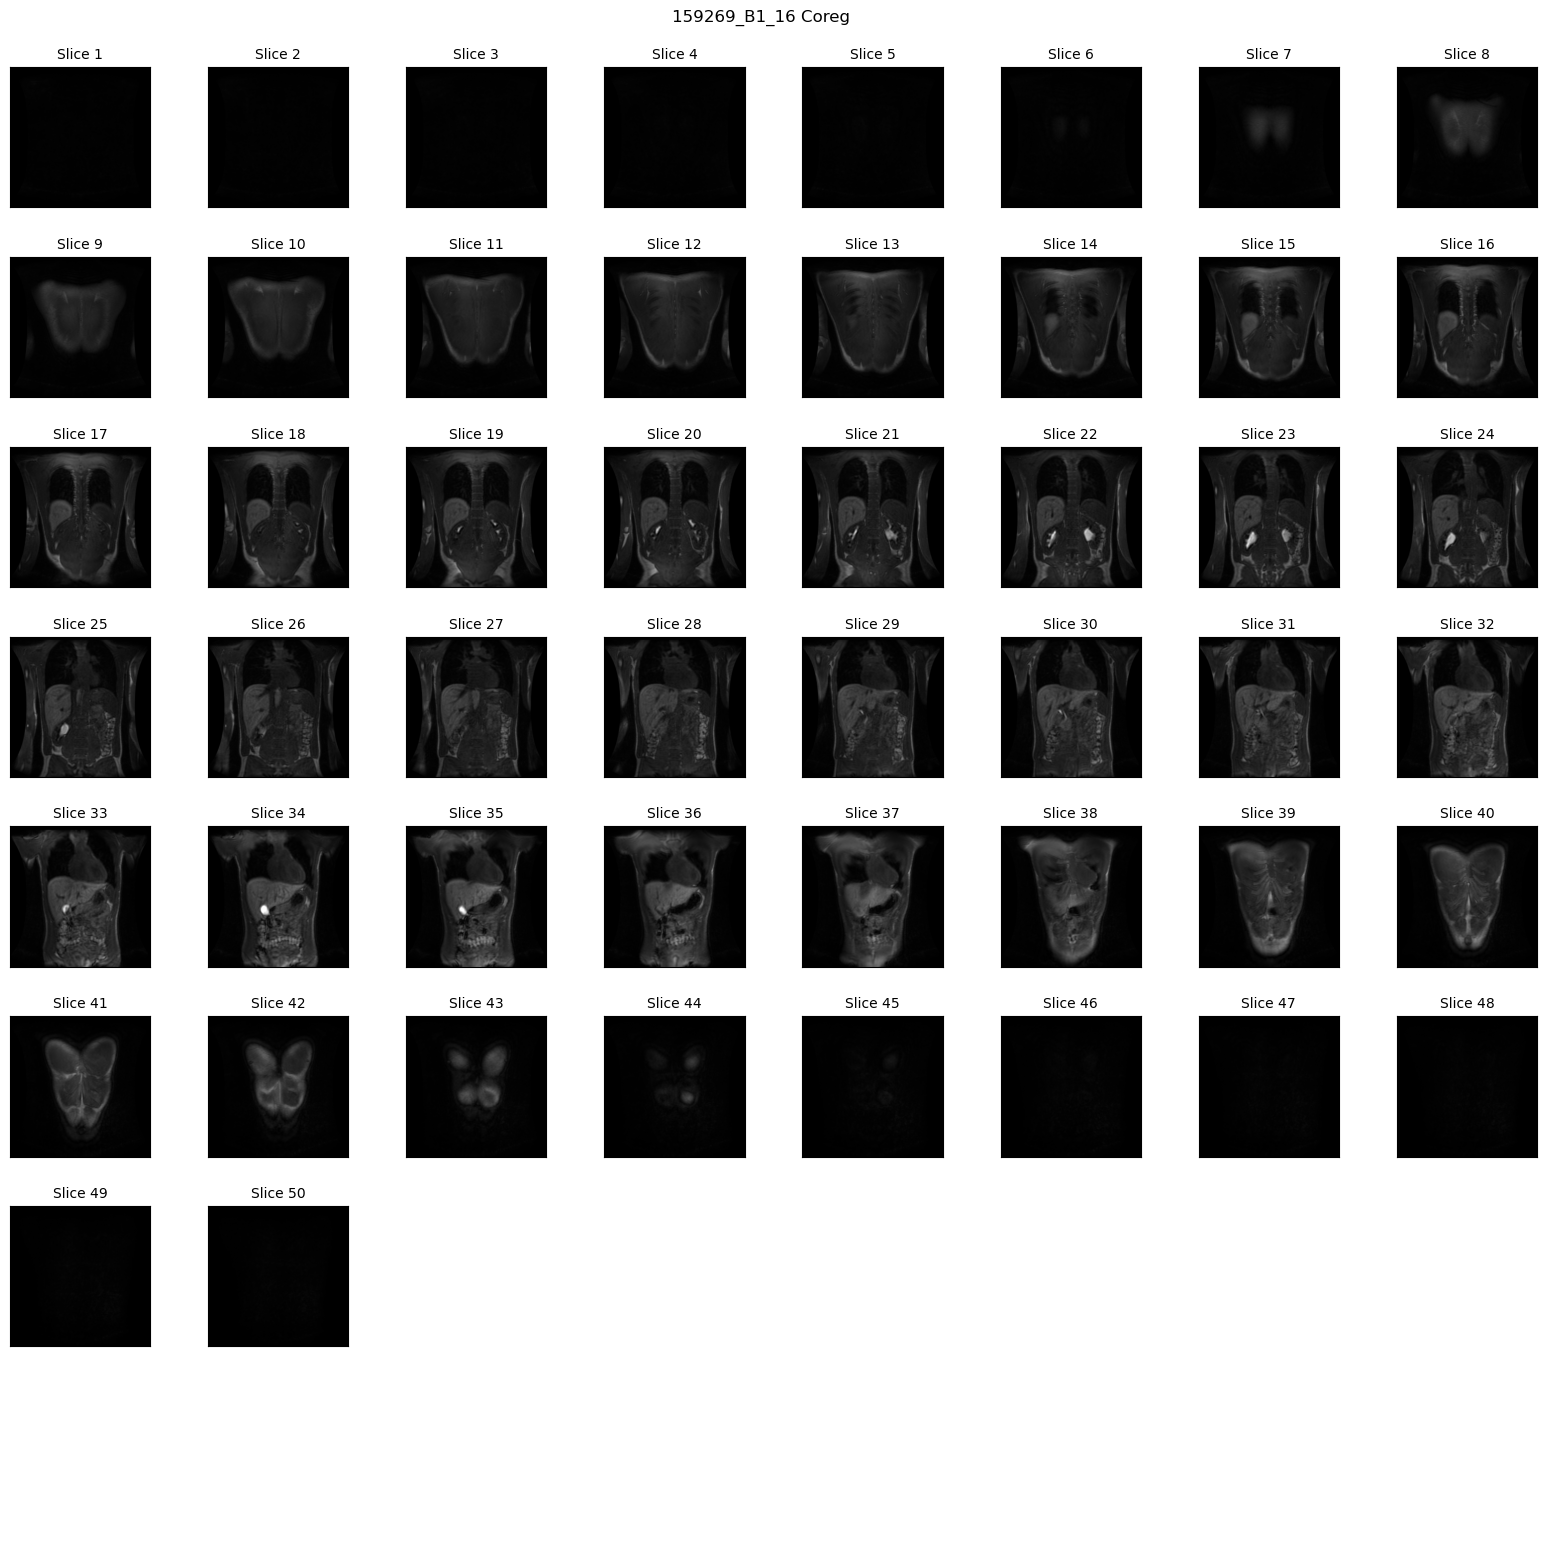

In [11]:
anim = mdreg.plot.animation(
    coreg_rotate[:,:,:, t0:t1],
    title=f"{DATASET_NAME}_{PART} Coreg",
    vmin=0,
    vmax=0.9*np.max(coreg[...,0],)
)

In [12]:
anim.save(f'{DATASET_NAME}_{PART}_Coreg.mpeg')

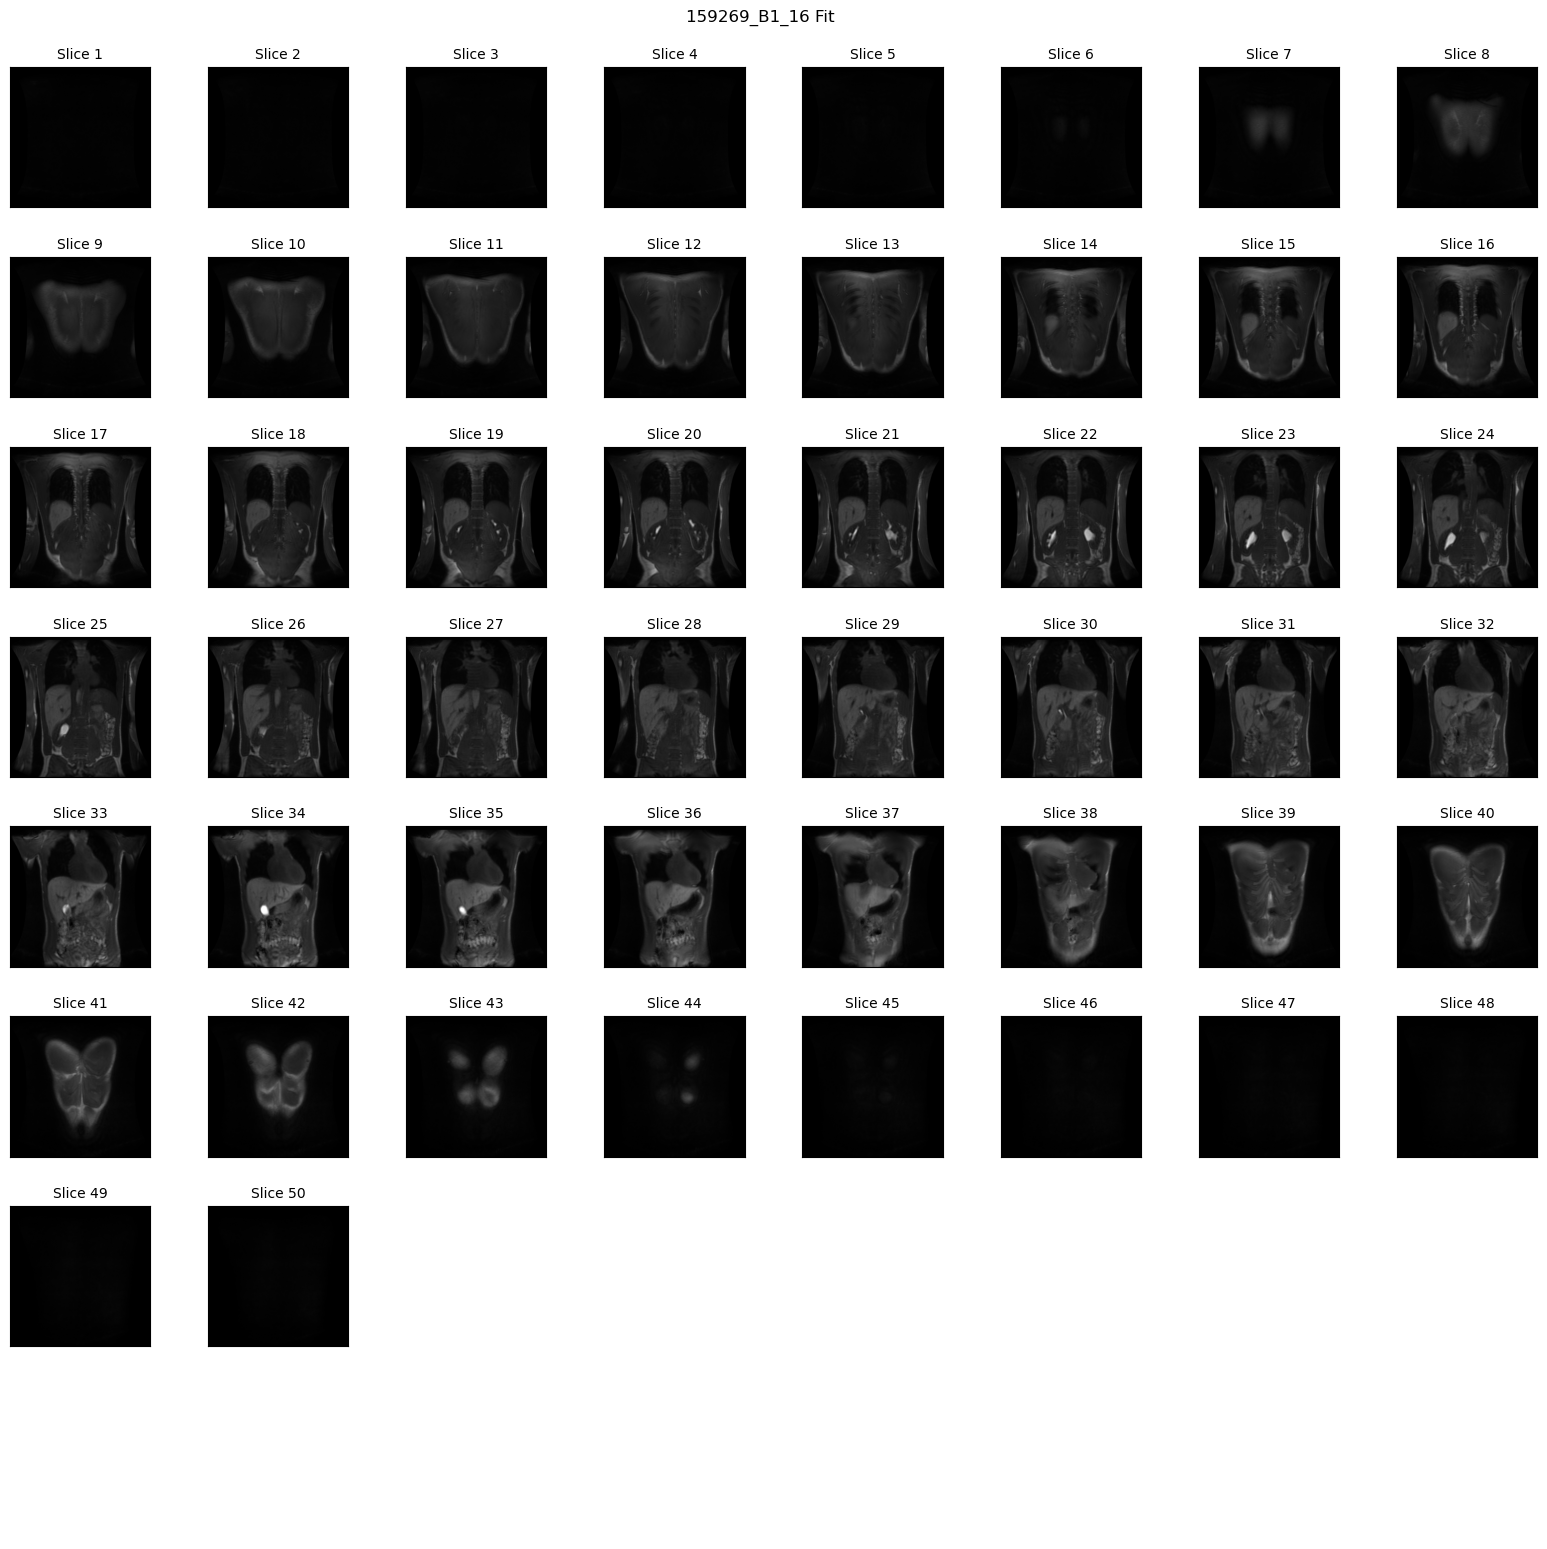

In [13]:
anim_fit = mdreg.plot.animation(
    fit_rotate[:,:,:, t0:t1],
    title=f"{DATASET_NAME}_{PART} Fit",
    vmin=0,
    vmax=0.9*np.max(fit_rotate[...,0],)
)

In [14]:
anim_fit.save(f'{DATASET_NAME}_{PART}_Fit.mpeg')

In [15]:
# Define paths (please adjust if needed)
dicom_folder = f'/mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/{DATASET_NAME}_{PART}/DICOM' 
zarr_file = f'/mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/{DATASET_NAME}/{PART}/{DATASET_NAME}_{PART}.zarr'
file_path = f'/mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/{DATASET_NAME}/{PART}/AIF.txt'
results_path = f'/mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/{DATASET_NAME}_{PART}/'

In [16]:
import os
import dicom_to_zarr

In [17]:
# Make sure the folder exists before calling the function
if not os.path.exists(dicom_folder):
    os.makedirs(dicom_folder)
    print(f"Folder '{dicom_folder}' was created. Please fill it with your DICOM files.")
elif not os.listdir(dicom_folder):
    print(f"The folder '{dicom_folder}' is empty. Please add DICOM files to run the script.")
else:
    # Call the conversion function
    dicom_to_zarr.convert_dicom_to_zarr(dicom_folder, zarr_file)

Lese DICOM-Dateien aus: /mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/159269_B1_16/DICOM
Stapele DICOM-Schichten zu einem 3D-Raum...
Extrahierte Metadaten: {'PixelSpacing': [1.9531, 1.9531], 'SliceThickness': 5.0, 'Rows': 256, 'Columns': 256, 'PatientID': 'MEDCIC_10_B1'}
Speichere Array der Größe (12500, 256, 256) in /mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/159269_B1/16/159269_B1_16.zarr...
Konvertierung abgeschlossen!


In [18]:
raw = zarr.open(zarr_file)
raw

<Array file:///mnt/dev_rep/repos/MRI-MoCoCo/ready_to_use/MRI-Datasets/mdreg_motion_correction_results/159269_B1/16/159269_B1_16.zarr shape=(12500, 256, 256) dtype=int16>

In [19]:
import dask.array as da

In [20]:
temp_zarr = 'input_zarr_for_mdreg_parallel_02.zarr'

In [21]:
# --- 1. Setup: Erstelle ein Dummy-Array mit Ihrer Start-Form ---
# Dies simuliert Ihr geladenes Zarr-Array.
input_array = da.from_zarr(raw)

# --- 2. Definition der Zieldimensionen ---
H, W = 256, 256 # Höhe und Breite bleiben gleich
D = 50 # 50 Bilder pro Zeitaufnahme bilden die neue Tiefen-Dimension (Z-Richtung)
T = 250 # 250 zeitlich versetzte Aufnahmen

# Überprüfung: 50 * 250 muss 12500 ergeben.
assert D * T == input_array.shape[0], "Die Dimensionen passen nicht zusammen!"

# --- 3. Umformung und Neuordnung der Achsen ---

# Schritt A: Umformen (Reshape)
# Wir interpretieren die 12500 Bilder als 250 Zeitpunkte (T) mit je 50 Tiefenschichten (D).
# Das Ergebnis hat die Form (T, D, H, W).
reshaped_array = input_array.reshape(T, D, H, W)
print(f"Form nach dem Reshape: {reshaped_array.shape}  (entspricht T, D, H, W)")

# Schritt B: Achsen neuordnen (Transpose)
# Wir bringen die Achsen in die gewünschte Reihenfolge (H, W, D, T).
# Alte Achsen: 0=T, 1=D, 2=H, 3=W
# Neue Reihenfolge: 2, 3, 1, 0
final_array = reshaped_array.transpose(2, 3, 1, 0)
print(f"Form des finalen Arrays: {final_array.shape} (entspricht H, W, D, T)")

# --- 4. Überprüfung ---
# Das finale Array hat nun die gewünschte Form (256, 256, 50, 250).
# Sie können es jetzt z.B. als neues Zarr-Array speichern.
final_array.to_zarr(temp_zarr, overwrite=True)
correct_shape_array = zarr.open(temp_zarr)

Form nach dem Reshape: (250, 50, 256, 256)  (entspricht T, D, H, W)
Form des finalen Arrays: (256, 256, 50, 250) (entspricht H, W, D, T)


In [22]:
raw_rotate = np.transpose(correct_shape_array, [1,0,2,3])

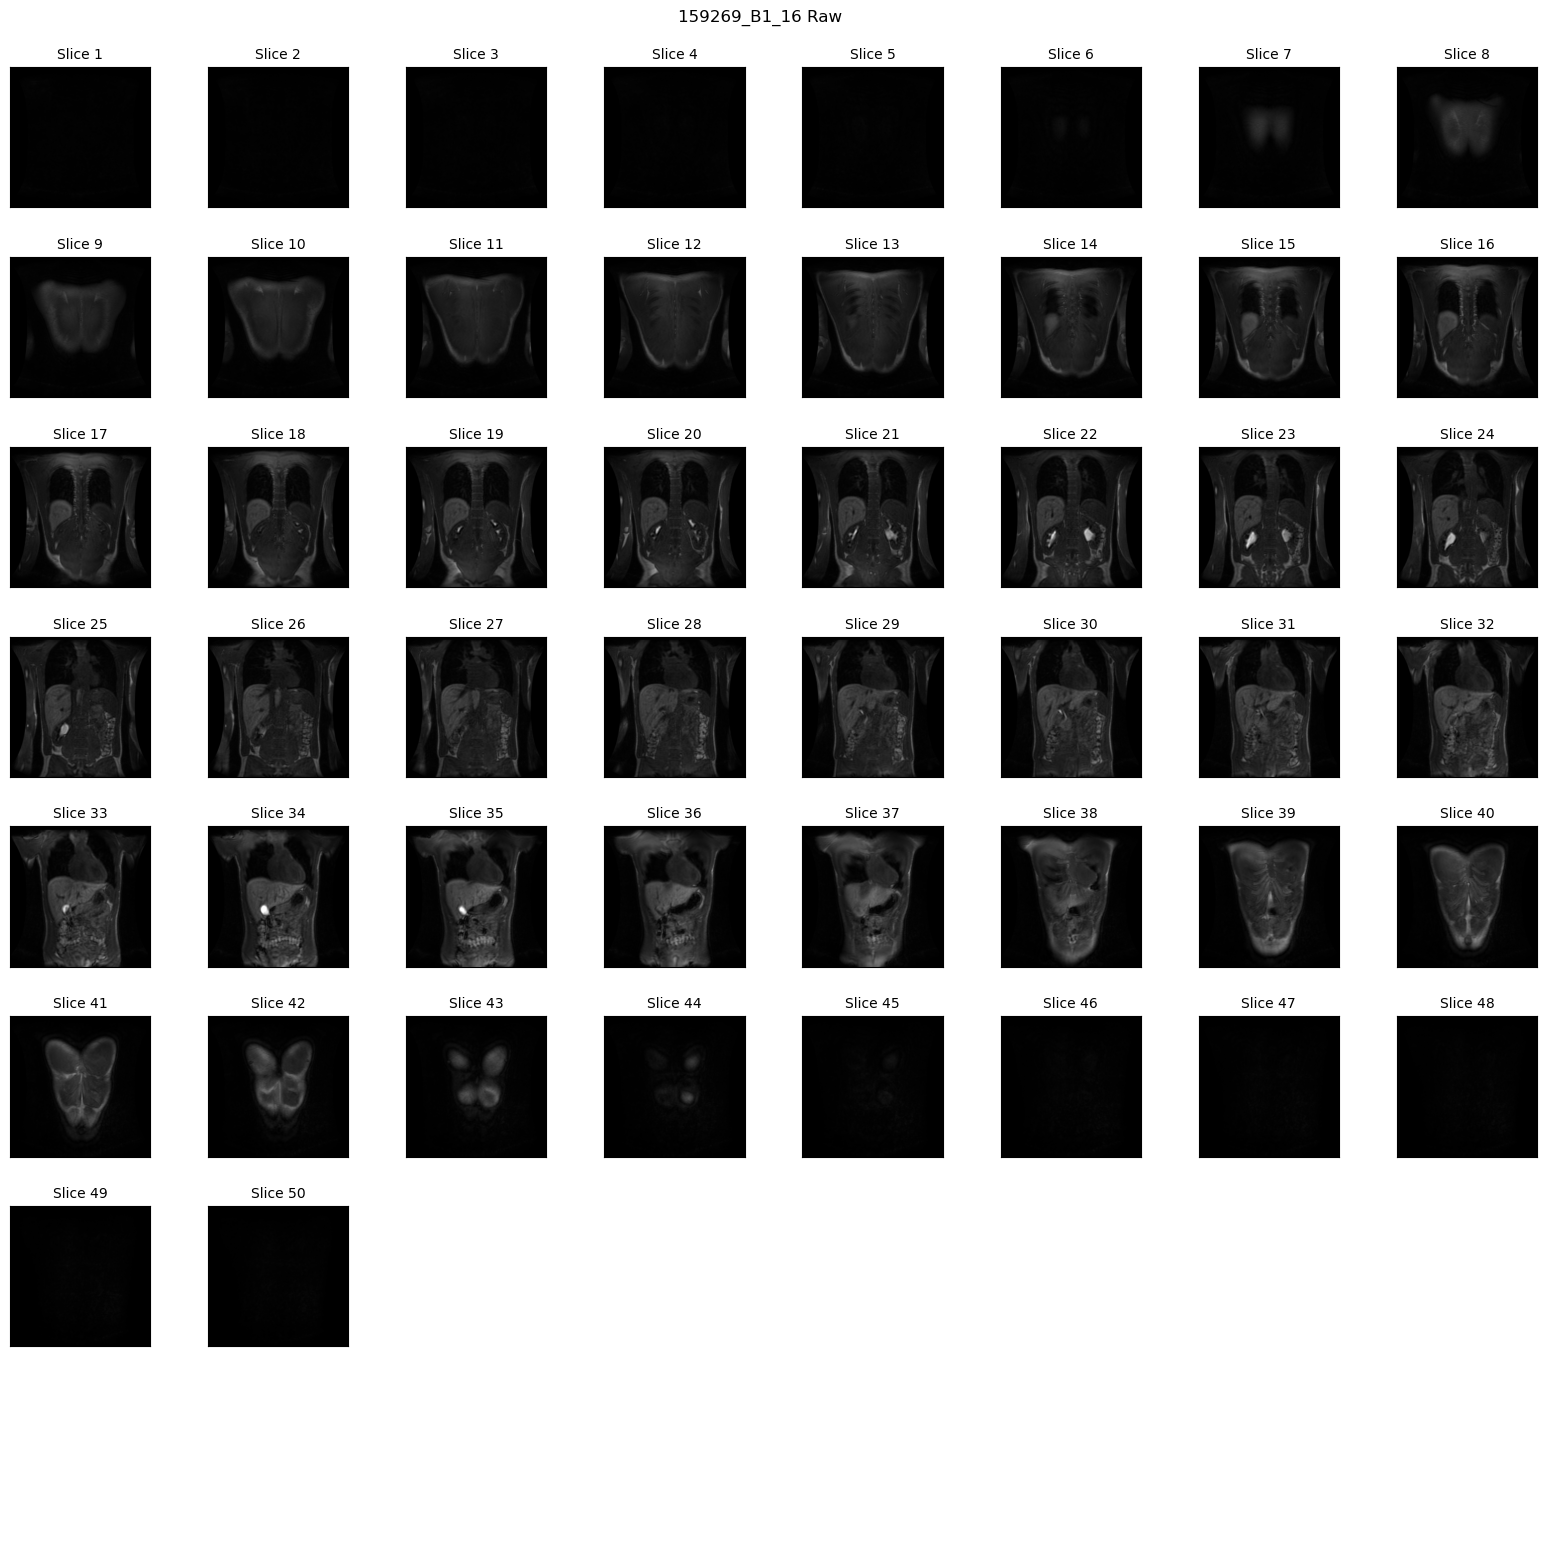

In [23]:
anim_raw = mdreg.plot.animation(
    raw_rotate[:,:,:, t0:t1],
    title=f"{DATASET_NAME}_{PART} Raw",
    vmin=0,
    vmax=0.9*np.max(raw_rotate[...,0],)
)

In [24]:
anim_raw.save(f'{DATASET_NAME}_{PART}_Raw.mpeg')